In [40]:
from sunpy.net import hek, hek2vso, attrs as a
import numpy as np

client = hek.HEKClient()
h2v = hek2vso.H2VClient()

tstart = '2011-01-20 00:00:00'
tend   = '2011-01-20 23:59:59'

filaments = client.search(
    a.Time(tstart, tend),
    hek.attrs.EventType('FI')
)


In [41]:
vso_records = h2v.translate_and_query(filaments[0]) # returns 11th filaments
print("Start time:", filaments['event_starttime'])
print("End time:", filaments['event_endtime'])
#print("Peak time:", filaments['event_peaktime'])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.30s/records]

Start time: ['2011-01-20 08:49:33.000' '2011-01-20 08:49:33.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000']
End time: ['2011-01-20 08:49:33.000' '2011-01-20 08:49:33.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000' '2011-01-20 18:18:35.000'
 '2011-01-20 18:18:35.000']


In [42]:
print(len(filaments))
print(filaments.colnames)

11
['gs_thumburl', 'comment_count', 'hpc_bbox', 'fi_barbstot', 'frm_humanflag', 'hgc_coord', 'event_coordsys', 'obs_levelnum', 'hpc_coord', 'event_npixels', 'gs_imageurl', 'ar_polarity', 'frm_paramset', 'hrc_coord', 'event_starttime', 'ar_mtwilsoncls', 'event_type', 'intensmin', 'obs_meanwavel', 'frm_url', 'skel_chaincode', 'bound_chaincode', 'noposition', 'active', 'intensmax', 'frm_versionnumber', 'area_uncert', 'obs_dataprepurl', 'hpc_geom', 'hgc_bbox', 'intensmedian', 'chaincodetype', 'obs_channelid', 'event_clippedspatial', 'ar_noaaclass', 'SOL_standard', 'event_avg_rating', 'eventtype', 'intensunit', 'hpc_boundcc', 'event_mapurl', 'frm_contact', 'ar_penumbracls', 'intensmean', 'fi_barbsendc2', 'bound_ccstartc1', 'fi_barbsendc1', 'frm_name', 'area_atdiskcenter', 'frm_identifier', 'obs_observatory', 'event_description', 'fi_barbsstartc2', 'boundbox_c2ur', 'fi_barbsstartc1', 'obs_firstprocessingdate', 'boundbox_c2ll', 'frm_institute', 'hrc_bbox', 'fi_lengthunit', 'refs_orig', 'hrc_s

In [43]:
xs = [e["hpc_x"] for e in filaments]
ys = [e["hpc_y"] for e in filaments]

print("Non-null x:", sum(x is not None for x in xs))
print("Non-null y:", sum(y is not None for y in ys))
xs = np.array([e["hpc_x"] for e in filaments], dtype=float)
ys = np.array([e["hpc_y"] for e in filaments], dtype=float)

print(xs.min(), xs.max())
print(ys.min(), ys.max())



Non-null x: 11
Non-null y: 11
-278.491 594.18
-766.101 585.132


In [44]:
%matplotlib inline


Saved filament tracks image as filtered_filaments.png


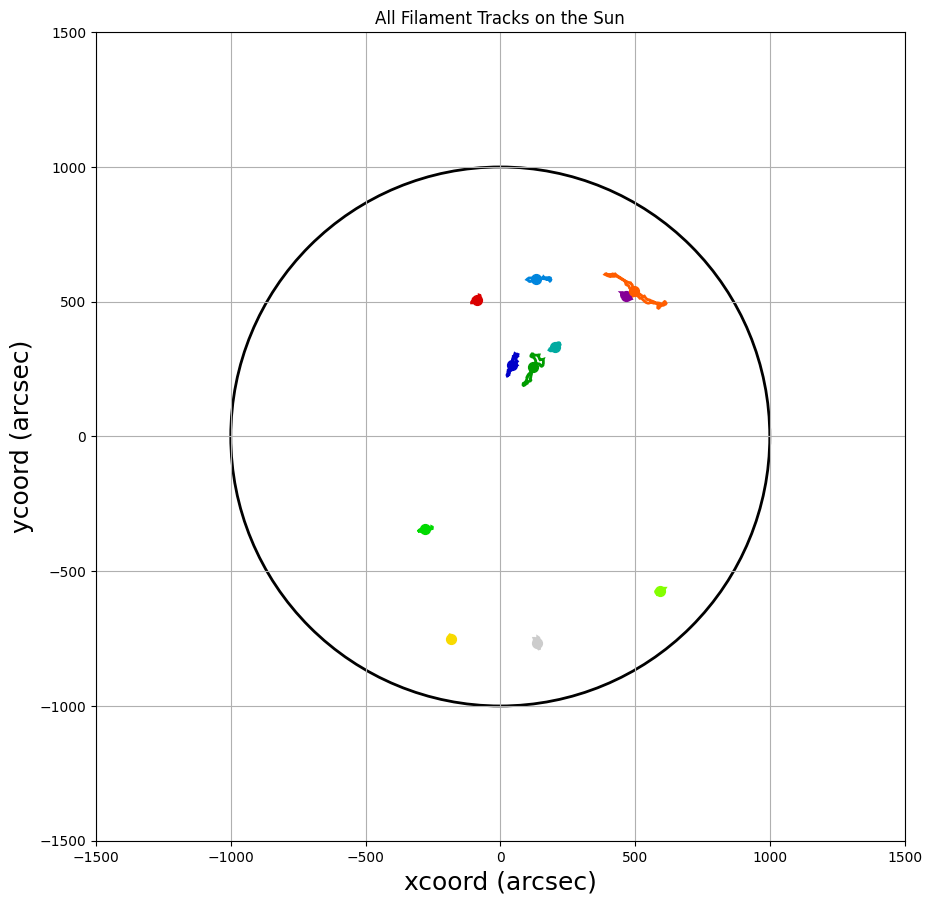

(<Figure size 1050x1050 with 1 Axes>,
 <Axes: title={'center': 'All Filament Tracks on the Sun'}, xlabel='xcoord (arcsec)', ylabel='ycoord (arcsec)'>)

In [49]:
from shapely import wkb
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
# plots all the filaments without separating timesteps taken at filaments[10 0r 1 or ...]
def PlotAllTracksFilteredSavePNG(filaments_table, png_filename="filaments_tracks.png"):
    """
    Plot all filaments from an Astropy Table,
    removing filaments with <=3 points, and save as PNG.
    """
    filaments = filaments_table.copy()

    # Add track numbers if missing
    if "trackno" not in filaments.colnames:
        filaments["trackno"] = range(1, len(filaments) + 1)

    track_numbers = sorted(set(filaments["trackno"]))

    # Color map
    cmap = plt.get_cmap('nipy_spectral')
    norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
    m = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Plot setup
    fig, ax = plt.subplots(figsize=(10.5, 10.5))
    ax.grid(True)
    ax.set_xlabel('xcoord (arcsec)', fontsize=18)
    ax.set_ylabel('ycoord (arcsec)', fontsize=18)
    ax.set_xlim(-1500, 1500)
    ax.set_ylim(-1500, 1500)
    ax.set_aspect('equal')

    # Solar disk
    sun_disk = plt.Circle((0, 0), radius=1000, linewidth=2, fill=False, color='black', zorder=1)
    ax.add_patch(sun_disk)

    # Loop over tracks
    for tn in track_numbers:
        color = m.to_rgba(tn)
        filaments_track = filaments[filaments["trackno"] == tn]

        # Plot eruption points
        xs = [x for x in filaments_track["hpc_x"] if x is not None]
        ys = [y for y in filaments_track["hpc_y"] if y is not None]
        ax.scatter(xs, ys, color=color, s=50, zorder=3)

        # Plot filament (first in track)
        filament_wkb_hex = filaments_track["hpc_geom"][0] if "hpc_geom" in filaments.colnames else None
        if filament_wkb_hex:
            try:
                poly = wkb.loads(bytes.fromhex(filament_wkb_hex))
            except Exception as e:
                print(f"Failed to parse filament WKB for track {tn}: {e}")
                continue

            # Filter out polygons with <=3 points
            def valid_polygon(polygon):
                return len(polygon.exterior.coords) > 3

            if poly:
                def plot_poly(polygon, color):
                    if valid_polygon(polygon):
                        ax.add_patch(plt.Polygon(polygon.exterior.coords,
                                                 linewidth=2, fill=False, color=color, zorder=2))

                if poly.geom_type == 'MultiPolygon':
                    for p in poly.geoms:
                        plot_poly(p, color)
                elif poly.geom_type == 'Polygon':
                    plot_poly(poly, color)
                else:
                    print(f"Unknown geometry type for track {tn}: {poly.geom_type}")

    ax.set_title('All Filament Tracks on the Sun')

    # --- Save PNG ---
    fig.savefig(png_filename, dpi=300, bbox_inches='tight')
    print(f"Saved filament tracks image as {png_filename}")

    # Optionally display
    plt.show()

    return fig, ax

# --- Usage ---
PlotAllTracksFilteredSavePNG(filaments, png_filename="filtered_filaments.png")


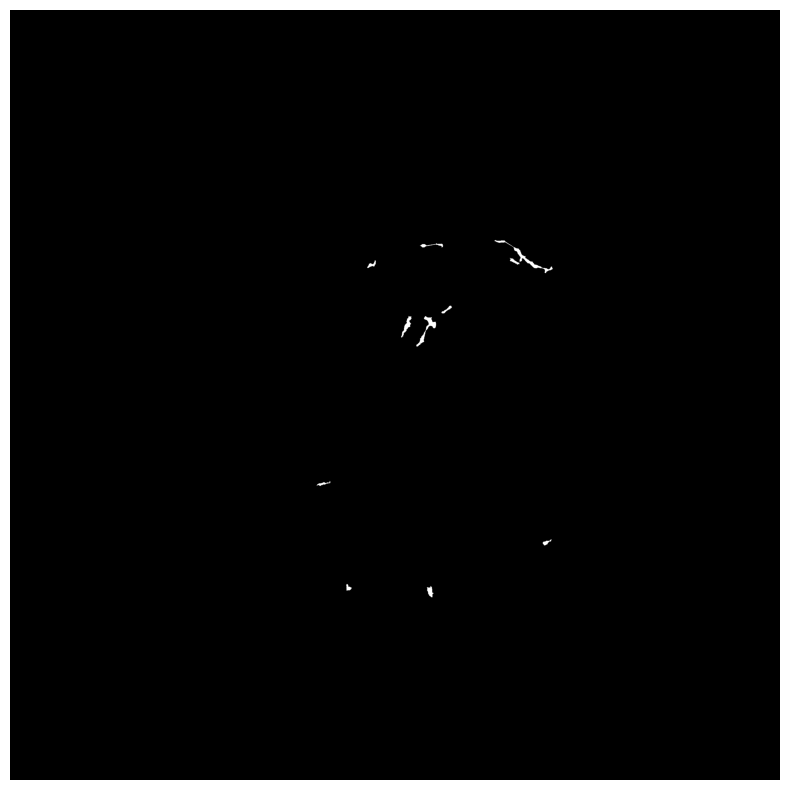

In [46]:
import numpy as np
from shapely import wkb
import matplotlib.pyplot as plt
from matplotlib.path import Path

def FilamentsBinarySameScale(filaments_table, extent=(-1500, 1500, -1500, 1500), img_size=3000):
    """
    Convert filament tracks to a binary image with the same coordinates as your previous plot.
    extent = (xmin, xmax, ymin, ymax)
    img_size = number of pixels along each axis (square image)
    """
    xmin, xmax, ymin, ymax = extent
    img = np.zeros((img_size, img_size), dtype=np.uint8)

    # Map solar coordinates to pixel indices
    def coord_to_pixel(x, y):
        px = int((x - xmin) / (xmax - xmin) * (img_size - 1))
        py = int((y - ymin) / (ymax - ymin) * (img_size - 1))
        return px, py

    for filament in filaments_table:
        wkb_hex = filament.get("hpc_geom")
        if not wkb_hex:
            continue
        try:
            poly = wkb.loads(bytes.fromhex(wkb_hex))
        except:
            continue

        def fill_poly(polygon):
            coords = [coord_to_pixel(x, y) for x, y in polygon.exterior.coords]
            if len(coords) < 3:
                return
            path = Path(coords)
            # Generate grid of pixel coordinates
            x_grid, y_grid = np.meshgrid(np.arange(img_size), np.arange(img_size))
            points = np.vstack((x_grid.ravel(), y_grid.ravel())).T
            mask = path.contains_points(points).reshape((img_size, img_size))
            img[mask] = 255  # white

        if poly.geom_type == 'Polygon':
            fill_poly(poly)
        elif poly.geom_type == 'MultiPolygon':
            for p in poly.geoms:
                fill_poly(p)

    # Display
    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='gray', origin='lower', extent=extent)
    plt.axis('off')
    plt.show()

    return img

# Usage
binary_img = FilamentsBinarySameScale(filaments)


Found 2 unique timestamps.
Saved filament tracks for timestamp 2011-01-20 08:49:33.000 as filaments_pngs/filaments_20110120 084933.png


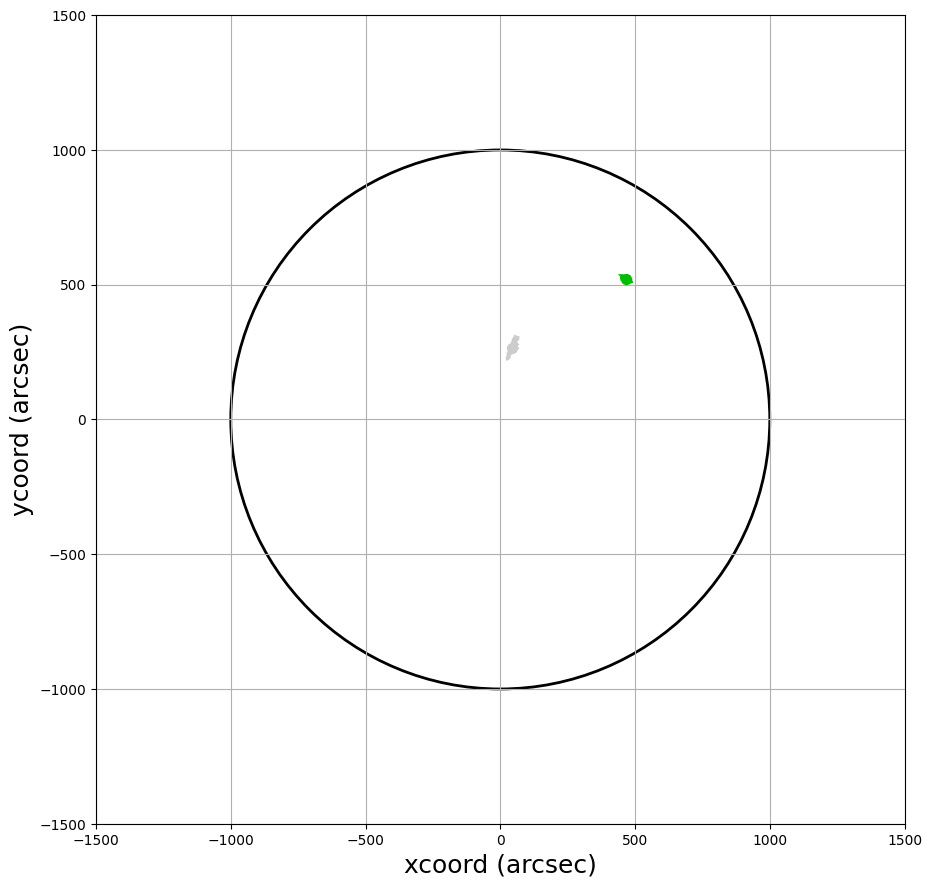

Saved filament tracks for timestamp 2011-01-20 18:18:35.000 as filaments_pngs/filaments_20110120 181835.png


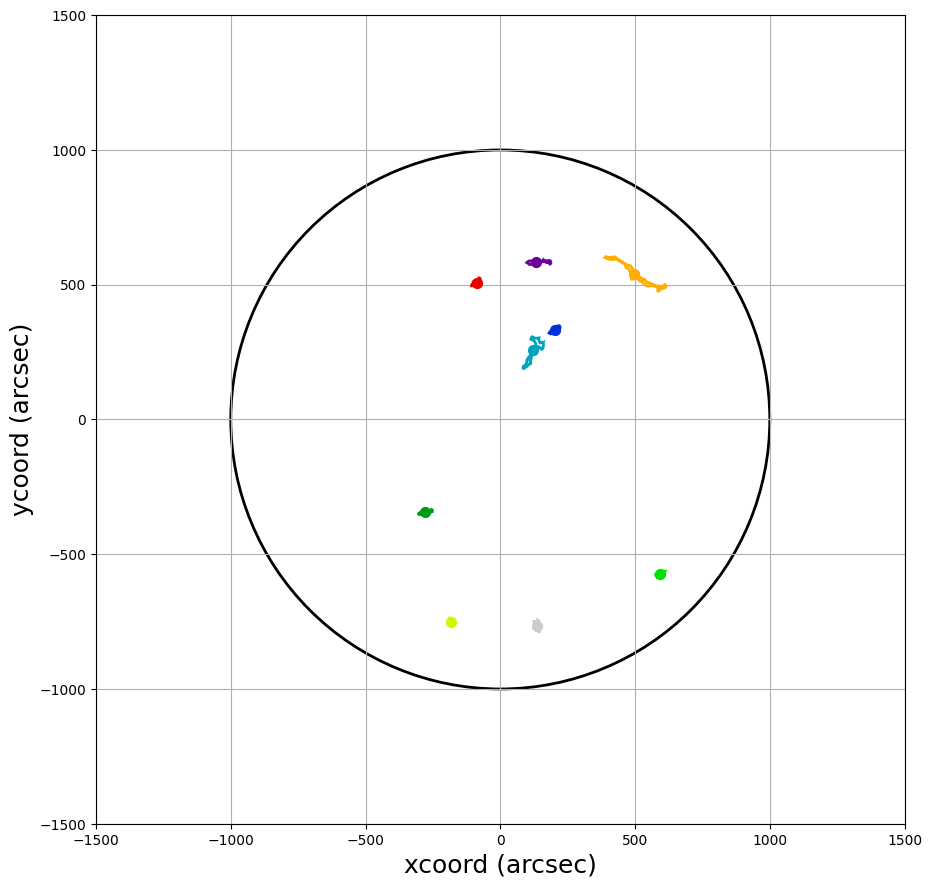

In [47]:
from shapely import wkb
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
from astropy.time import Time
import os

def PlotTracksAllTimestamps(filaments_table, output_dir="filaments_pngs"):
    """
    Automatically generate PNG images of filament tracks for all unique timestamps.
    
    filaments_table : Astropy Table with 'event_starttime' and 'hpc_geom'
    output_dir : folder where PNGs will be saved
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Convert start times to Astropy Time objects
    table_times = Time(filaments_table["event_starttime"])
    
    # Find unique timestamps
    unique_times = sorted(set(table_times))
    print(f"Found {len(unique_times)} unique timestamps.")
    
    for timestamp in unique_times:
        filaments_at_time = filaments_table[table_times == timestamp]
        
        if len(filaments_at_time) == 0:
            continue
        
        # Add track numbers if missing
        if "trackno" not in filaments_at_time.colnames:
            filaments_at_time["trackno"] = range(1, len(filaments_at_time) + 1)
        track_numbers = sorted(set(filaments_at_time["trackno"]))
        
        # Color map
        cmap = plt.get_cmap('nipy_spectral')
        norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
        m = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        
        # Plot setup
        fig, ax = plt.subplots(figsize=(10.5, 10.5))
        ax.grid(True)
        ax.set_xlabel('xcoord (arcsec)', fontsize=18)
        ax.set_ylabel('ycoord (arcsec)', fontsize=18)
        ax.set_xlim(-1500, 1500)
        ax.set_ylim(-1500, 1500)
        ax.set_aspect('equal')
        
        # Solar disk
        sun_disk = plt.Circle((0, 0), radius=1000, linewidth=2, fill=False, color='black', zorder=1)
        ax.add_patch(sun_disk)
        
        # Loop over tracks
        for tn in track_numbers:
            color = m.to_rgba(tn)
            filaments_track = filaments_at_time[filaments_at_time["trackno"] == tn]
            
            # Plot eruption points
            xs = [x for x in filaments_track["hpc_x"] if x is not None]
            ys = [y for y in filaments_track["hpc_y"] if y is not None]
            ax.scatter(xs, ys, color=color, s=50, zorder=3)
            
            # Plot filament (first eruption in track)
            filament_wkb_hex = filaments_track["hpc_geom"][0] if "hpc_geom" in filaments_track.colnames else None
            if filament_wkb_hex:
                try:
                    poly = wkb.loads(bytes.fromhex(filament_wkb_hex))
                except Exception as e:
                    print(f"Failed to parse filament WKB for track {tn}: {e}")
                    continue
                
                def valid_polygon(polygon):
                    return len(polygon.exterior.coords) > 3
                
                if poly:
                    def plot_poly(polygon, color):
                        if valid_polygon(polygon):
                            ax.add_patch(plt.Polygon(polygon.exterior.coords,
                                                     linewidth=2, fill=False, color=color, zorder=2))
                    
                    if poly.geom_type == 'MultiPolygon':
                        for p in poly.geoms:
                            plot_poly(p, color)
                    elif poly.geom_type == 'Polygon':
                        plot_poly(poly, color)
        
        # Save PNG
        timestamp_str = timestamp.iso.replace(":", "").replace("-", "").replace("T", "_")[:15]
        png_filename = os.path.join(output_dir, f"filaments_{timestamp_str}.png")
        fig.savefig(png_filename, dpi=300, bbox_inches='tight')
        print(f"Saved filament tracks for timestamp {timestamp.iso} as {png_filename}")
        #plt.close(fig)
        plt.show()

# --- Usage ---
PlotTracksAllTimestamps(filaments)
#plt.show()


In [48]:
import numpy as np
from astropy.io import fits
from shapely import wkb
from shapely.geometry import Polygon, MultiPolygon
from matplotlib.path import Path
from astropy.time import Time
import os
import matplotlib.pyplot as plt

def FilamentsBinaryFITS_single(filaments_table, img_size=4096,
                               extent=(-1500,1500,-1500,1500),
                               fits_filename="filaments.fits",
                               png_filename=None):
    """
    Create a binary filament image, save as FITS and optionally PNG.
    """
    xmin, xmax, ymin, ymax = extent
    img = np.zeros((img_size, img_size), dtype=np.uint8)

    # Map solar coordinates to pixel indices
    def coord_to_pixel(x, y):
        px = int((x - xmin) / (xmax - xmin) * (img_size - 1))
        py = int((y - ymin) / (ymax - ymin) * (img_size - 1))
        return px, py

    # Loop over filaments
    for filament in filaments_table:
        wkb_hex = filament.get("hpc_geom")
        if not wkb_hex:
            continue
        try:
            poly = wkb.loads(bytes.fromhex(wkb_hex))
        except:
            continue

        def fill_poly(polygon):
            coords = [coord_to_pixel(x, y) for x, y in polygon.exterior.coords]
            if len(coords) < 3:
                return
            path = Path(coords)
            x_grid, y_grid = np.meshgrid(np.arange(img_size), np.arange(img_size))
            points = np.vstack((x_grid.ravel(), y_grid.ravel())).T
            mask = path.contains_points(points).reshape((img_size, img_size))
            img[mask] = 255  # white

        if poly.geom_type == 'Polygon':
            fill_poly(poly)
        elif poly.geom_type == 'MultiPolygon':
            for p in poly.geoms:
                fill_poly(p)

    # Save as FITS
    hdu = fits.PrimaryHDU(img)
    hdu.header['CTYPE1'] = 'HPLN-TAN'
    hdu.header['CTYPE2'] = 'HPLT-TAN'
    hdu.header['CRPIX1'] = img_size // 2
    hdu.header['CRPIX2'] = img_size // 2
    hdu.header['CRVAL1'] = 0.0
    hdu.header['CRVAL2'] = 0.0
    hdu.header['CDELT1'] = (xmax - xmin) / img_size
    hdu.header['CDELT2'] = (ymax - ymin) / img_size
    hdu.writeto(fits_filename, overwrite=True)
    print(f"Saved binary filament image to {fits_filename}")

    # Save as PNG if requested
    if png_filename:
        plt.imsave(png_filename, img, cmap='gray', origin='lower')
        print(f"Saved binary filament PNG image to {png_filename}")

    return img

def FilamentsBinaryFITS_all_times(filaments_table, output_dir="filaments_fits", img_size=4096):
    """
    Generate binary FITS and PNG images for each unique timestamp in the table.
    """
    os.makedirs(output_dir, exist_ok=True)

    table_times = Time(filaments_table["event_starttime"])
    unique_times = sorted(set(table_times))
    print(f"Found {len(unique_times)} unique timestamps.")

    for timestamp in unique_times:
        filaments_at_time = filaments_table[table_times == timestamp]
        if len(filaments_at_time) == 0:
            continue

        timestamp_str = timestamp.iso.replace(":", "").replace("-", "").replace("T", "_")[:15]
        fits_filename = os.path.join(output_dir, f"filaments_{timestamp_str}.fits")
        png_filename  = os.path.join(output_dir, f"filaments_{timestamp_str}.png")

        FilamentsBinaryFITS_single(filaments_at_time,
                                   img_size=img_size,
                                   fits_filename=fits_filename,
                                   png_filename=png_filename)

# --- Usage ---
FilamentsBinaryFITS_all_times(filaments, output_dir="filaments_4096", img_size=4096)


Found 2 unique timestamps.
Saved binary filament image to filaments_4096/filaments_20110120 084933.fits
Saved binary filament PNG image to filaments_4096/filaments_20110120 084933.png
Saved binary filament image to filaments_4096/filaments_20110120 181835.fits
Saved binary filament PNG image to filaments_4096/filaments_20110120 181835.png


In [50]:
all_filaments = client.search(
    a.Time(tstart, tend),
    hek.attrs.EventType('FI')
)

set(all_filaments['obs_observatory'])


{'BBSO', 'KANZELHOEHE OBSERVATORY'}